# Proyek Analisis Data: [E-commerce-public-dataset]
- **Nama:** Avelina Garcia Wong
- **Email:** [avelina.g.wong20@gmail.com]
- **ID Dicoding:** [cdcc834d6x1273]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Produk apa yang paling banyak dibeli oleh segmen pelanggan yang mmemberikan kontribusi besar terhadap total revenue berdasarkan analisis RFM (Recency, Frequency, Monetary) selama periode September 2016 - Oktober 2018?

- **Pertanyaan 2:** Kategori produk apa yang paling banyak berkontribusi terhadap total revenue, dan bagaimana distribusi pembeliannya di setiap segmen pelanggan?

- **Pertanyaan 3:** Bagaimana performa waktu pengiriman di berbagai wilayah, dan wilayah mana yang memiliki pengiriman paling cepat selama periode September 2016 - Oktober 2018?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

#### Load df ...

In [3]:
 # load dataset
customers=pd.read_csv('customers_dataset.csv')
geolocation=pd.read_csv('geolocation_dataset.csv', engine='python')
order_items=pd.read_csv('order_items_dataset.csv')
order_payments=pd.read_csv('order_payments_dataset.csv')
order_reviews=pd.read_csv('order_reviews_dataset.csv')
orders=pd.read_csv('orders_dataset.csv')
category=pd.read_csv('product_category_name_translation.csv')
products=pd.read_csv('products_dataset.csv')
sellers=pd.read_csv('sellers_dataset.csv')

In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
#Merge orders dengan order_items
df = orders[['order_id','customer_id','order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']].merge(order_items[['order_id','product_id','seller_id','price','freight_value']], on='order_id', how='left')

#Merge dengan customers
df=df.merge(customers, on='customer_id', how='left')

#Merge dengan sellers
df=df.merge(sellers, on='seller_id', how='left')

# Merge dengan products
df = df.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

#  Merge dengan kategori
df = df.merge(
    category,
    on='product_category_name',
    how='left'
)

df.rename(columns={'product_category_name_english': 'category'}, inplace=True)

df.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752.0,mogi das cruzes,SP,papelaria,stationery


**Insight:** (Opsional)
*  Dari sisi pelanggan, keberadaan customer_unique_id memungkinkan analisis berbasis individu, sehingga pendekatan RFM (Recency, Frequency, Monetary) dapat diterapkan dengan baik. Hal ini penting karena tidak hanya mengidentifikasi pelanggan dengan total pembelian terbesar, tetapi juga mempertimbangkan seberapa sering dan seberapa baru mereka bertransaksi. Insight yang dapat diperoleh adalah identifikasi segmen pelanggan bernilai tinggi yang menjadi kontributor utama revenue, yang nantinya dapat digunakan untuk strategi retensi atau loyalty program.
*  Dari sisi produk dan kategori, kombinasi product_id dan category memberikan peluang untuk menganalisis preferensi pembelian secara lebih mendalam. Dataset ini memungkinkan identifikasi produk yang paling sering dibeli oleh segmen pelanggan bernilai tinggi, serta kategori produk yang paling berkontribusi terhadap total revenue. Insight ini sangat berguna untuk pengambilan keputusan bisnis seperti pengelolaan stok, promosi produk tertentu, hingga strategi bundling berdasarkan perilaku pelanggan.
*   Selain itu, dimensi geografis melalui customer_state dan seller_state memungkinkan analisis distribusi transaksi berdasarkan wilayah. Hal ini dapat memberikan gambaran mengenai daerah dengan aktivitas pembelian tinggi maupun rendah, serta potensi perbedaan performa antar wilayah. Ketika dikombinasikan dengan data waktu pengiriman (order_purchase_timestamp dan order_delivered_customer_date), analisis dapat diperluas untuk mengevaluasi efisiensi logistik di masing-masing wilayah. Meskipun tidak ditemukan banyak keterlambatan (delay), analisis durasi pengiriman tetap relevan untuk mengidentifikasi wilayah dengan performa pengiriman tercepat dan sebagai benchmark operasional.

### Assessing Data

#### Identifying ... problem

In [6]:
#Overview data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_purchase_timestamp       113425 non-null  object 
 3   order_delivered_customer_date  110196 non-null  object 
 4   order_estimated_delivery_date  113425 non-null  object 
 5   product_id                     112650 non-null  object 
 6   seller_id                      112650 non-null  object 
 7   price                          112650 non-null  float64
 8   freight_value                  112650 non-null  float64
 9   customer_unique_id             113425 non-null  object 
 10  customer_zip_code_prefix       113425 non-null  int64  
 11  customer_city                  113425 non-null  object 
 12  customer_state                

In [7]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752.0,mogi das cruzes,SP,papelaria,stationery


In [8]:
df.describe(include='all')

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,category
count,113425,113425,113425,110196,113425,112650,112650,112650.000000,112650.000000,113425,113425.000000,113425,113425,112650.000000,112650,112650,111047,111023
unique,99441,99441,98875,95664,459,32951,3095,NaN,NaN,96096,NaN,4119,27,NaN,611,23,73,71
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,2017-07-31 18:03:02,2017-12-20 00:00:00,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,c8460e4251689ba205045f3ea17884a1,NaN,sao paulo,SP,NaN,sao paulo,SP,cama_mesa_banho,bed_bath_table
freq,21,21,21,21,611,527,2033,NaN,NaN,24,NaN,17946,47820,NaN,27983,80342,11115,11115
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.653739,19.990320,NaN,35102.472965,NaN,NaN,24439.170431,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,183.633928,15.806405,NaN,29864.919733,NaN,NaN,27596.030909,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.850000,0.000000,NaN,1003.000000,NaN,NaN,1001.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.900000,13.080000,NaN,11250.000000,NaN,NaN,6429.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.990000,16.260000,NaN,24320.000000,NaN,NaN,13568.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134.900000,21.150000,NaN,59020.000000,NaN,NaN,27930.000000,NaN,NaN,NaN,NaN


In [9]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_purchase_timestamp,0
order_delivered_customer_date,3229
order_estimated_delivery_date,0
product_id,775
seller_id,775
price,775
freight_value,775
customer_unique_id,0


In [10]:
# Cek duplikasi data
df.duplicated().sum()

np.int64(10225)

In [11]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752.0,mogi das cruzes,SP,papelaria,stationery


In [12]:
# Cek Duplikat berdasarkan order_id
df['order_id'].duplicated().sum()

np.int64(13984)

In [13]:
# Cek Invalid Value
df[df['price'] < 0]
df[df['freight_value'] < 0]

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,category


In [14]:
df.dtypes

,0
order_id,object
customer_id,object
order_purchase_timestamp,object
order_delivered_customer_date,object
order_estimated_delivery_date,object
product_id,object
seller_id,object
price,float64
freight_value,float64
customer_unique_id,object


In [15]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752.0,mogi das cruzes,SP,papelaria,stationery


**Steps to Take:**
- Pertama, mengubah tipe data kolom waktu seperti order_purchase_timestamp, order_delivered_customer_date, dan order_estimated_delivery_date ke format datetime agar bisa digunakan untuk perhitungan waktu.
- Kedua, membuat variabel baru yaitu total_price (price + freight_value) untuk merepresentasikan total transaksi, serta shipping duration untuk menghitung selisih antara waktu pengiriman dan waktu pemesanan
- Ketiga, menangani missing value dengan menghapus data yang tidak memiliki informasi penting, terutama pada kolom pengiriman dan nilai transaksi.
- Keempat, melakukan agregasi data ke level transaksi (order_id) agar tidak terjadi duplikasi akibat satu order memiliki beberapa item.


**Insight:** (Opsional)
- Pertama, terdapat missing value yang cukup signifikan pada beberapa kolom kunci seperti order_delivered_customer_date, product_id, seller_id, serta atribut terkait produk (product_category_name dan category). Ini menunjukkan bahwa tidak semua transaksi memiliki informasi lengkap, khususnya terkait pengiriman dan detail produk. Kondisi ini berpotensi memengaruhi analisis yang berkaitan dengan performa pengiriman maupun analisis kategori produk. Artinya, jika tidak ditangani dengan tepat, hasil analisis bisa menjadi bias karena hanya merepresentasikan sebagian data saja.
- Kedua, ditemukan jumlah duplikasi yang cukup tinggi, baik secara keseluruhan maupun berdasarkan order_id. Namun ini bukan langsung berarti “data salah”. Dalam konteks e-commerce, satu order_id memang bisa muncul beberapa kali karena satu pesanan dapat terdiri dari beberapa item (multi-produk). Jadi insight pentingnya: struktur data kamu adalah granularity per item, bukan per order. Ini krusial, karena kalau langsung dianalisis tanpa agregasi, bisa menyebabkan overcount (misalnya jumlah order terlihat lebih banyak dari yang sebenarnya).
- Ketiga, dari pengecekan invalid value, tidak ditemukan nilai negatif pada price maupun freight_value. Ini menunjukkan bahwa dari sisi logika bisnis, data transaksi sudah cukup konsisten dan valid. Artinya, kamu tidak perlu melakukan cleaning besar di bagian ini, dan bisa lebih fokus ke masalah lain seperti missing value dan duplikasi. - Keempat, tipe data menunjukkan bahwa kolom waktu (order_purchase_timestamp, order_delivered_customer_date, dll.) masih dalam bentuk object, bukan datetime. Ini menjadi insight penting karena tanpa konversi, kamu tidak bisa melakukan analisis berbasis waktu seperti RFM (recency), tren bulanan, atau durasi pengiriman. Jadi ini bukan sekadar technical issue, tapi langsung berdampak ke kemampuan menjawab pertanyaan bisnis. Kelima, dari statistik deskriptif, terlihat bahwa distribusi price dan freight_value cukup lebar (range besar antara minimum dan maksimum).

### Cleaning Data

#### Fixing ... problem

In [16]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'],
    errors='coerce'
).dt.normalize()

df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date'],
    errors='coerce'
).dt.normalize()

df['order_estimated_delivery_date'] = pd.to_datetime(
    df['order_estimated_delivery_date'],
    errors='coerce'
).dt.normalize()

In [17]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02,2017-10-10,2017-10-18,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,2018-08-07,2018-08-13,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,2018-08-17,2018-09-04,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18,2017-12-02,2017-12-15,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13,2018-02-16,2018-02-26,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752.0,mogi das cruzes,SP,papelaria,stationery


In [18]:
# Hapus missing value
df = df.dropna(subset=['seller_id','category','order_delivered_customer_date'])
df = df.dropna(subset=['price', 'freight_value'])
df = df.dropna(subset=['seller_zip_code_prefix','seller_city','seller_state'])

In [19]:
# Buat kolom baru
df['total_price'] = df['price'] + df['freight_value']
df['shipping_duration'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108637 entries, 0 to 113424
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       108637 non-null  object        
 1   customer_id                    108637 non-null  object        
 2   order_purchase_timestamp       108637 non-null  datetime64[ns]
 3   order_delivered_customer_date  108637 non-null  datetime64[ns]
 4   order_estimated_delivery_date  108637 non-null  datetime64[ns]
 5   product_id                     108637 non-null  object        
 6   seller_id                      108637 non-null  object        
 7   price                          108637 non-null  float64       
 8   freight_value                  108637 non-null  float64       
 9   customer_unique_id             108637 non-null  object        
 10  customer_zip_code_prefix       108637 non-null  int64         
 11  custo

In [21]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name,category,total_price,shipping_duration
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02,2017-10-10,2017-10-18,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,utilidades_domesticas,housewares,38.71,8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,2018-08-07,2018-08-13,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,perfumaria,perfumery,141.46,14
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,2018-08-17,2018-09-04,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,automotivo,auto,179.12,9
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18,2017-12-02,2017-12-15,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop,pet_shop,72.20,14
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13,2018-02-16,2018-02-26,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752.0,mogi das cruzes,SP,papelaria,stationery,28.62,3


**Insight:** (Opsional)
- Setelah proses data cleaning, dataset menjadi lebih rapi, konsisten, dan siap digunakan untuk analisis lanjutan. Data bersifat item-level, di mana setiap baris merepresentasikan satu produk dalam satu transaksi, sehingga sangat cocok untuk analisis detail seperti revenue per produk dan kategori. Seluruh missing value pada kolom penting telah ditangani sehingga mengurangi risiko bias dalam analisis, khususnya pada RFM, analisis produk, dan performa pengiriman. Selain itu, dilakukan feature engineering dengan menambahkan kolom total_price yang menggabungkan harga produk dan biaya pengiriman, sehingga nilai revenue menjadi lebih representatif. Kolom shipping_duration juga menambah informasi penting mengenai variasi waktu pengiriman yang dapat dianalisis lebih lanjut berdasarkan wilayah, seller, atau kategori produk. Dari sisi struktur data, seluruh tipe data sudah sesuai, terutama kolom waktu yang telah dikonversi ke datetime sehingga memungkinkan analisis berbasis waktu seperti tren penjualan dan perhitungan recency dalam RFM.

## Exploratory Data Analysis (EDA)

### Explore ...

In [22]:
# Frekuensi Pembelian Customer
df.groupby('customer_id')['order_id'].count().describe()

,order_id
count,95125.000000
mean,1.142045
std,0.538660
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


In [23]:
# Total Spending Customer
df.groupby('customer_id')['total_price'].sum().describe()

,total_price
count,95125.000000
mean,159.955738
std,218.701362
min,9.590000
25%,61.980000
50%,105.150000
75%,176.810000
max,13664.080000


In [24]:
# produk dengan kontribusi revenue terbesar
df.groupby('product_id')['total_price'].sum().sort_values(ascending=False).head(10)

,total_price
product_id,
bb50f2e236e5eea0100680137654686c,67258.03
d1c427060a0f73f6b889a5c7c61f2ac4,58957.31
6cdd53843498f92890544667809f1595,57933.73
99a4788cb24856965c36a24e339b6058,49907.50
3dd2a17168ec895c781a9191c1e95ad7,47876.06
d6160fb7873f184099d9bc95e30376af,47314.18
aca2eb7d00ea1a7b8ebd4e68314663af,44197.75
5f504b3a1c75b73d6151be81eb05bdc9,41725.81
25c38557cf793876c5abdd5931f922db,40311.95


In [25]:
#Distribusi Waktu Pengiriman
df['shipping_duration'].describe()

,shipping_duration
count,108637.000000
mean,12.407145
std,9.444638
min,0.000000
25%,7.000000
50%,10.000000
75%,16.000000
max,210.000000


**Insight:** (Opsional)
- Hasil exploratory data analysis menunjukkan bahwa frekuensi pembelian pelanggan sangat rendah, di mana nilai mean sebesar 1.14 dan median 1 mengindikasikan bahwa mayoritas customer hanya melakukan satu kali transaksi (one-time buyer), meskipun terdapat sebagian kecil pelanggan dengan frekuensi pembelian hingga 21 kali yang menunjukkan adanya segmen pelanggan sangat aktif.
- Dari sisi total pengeluaran, rata-rata spending customer sebesar 159.96 dengan median 105.15 menunjukkan bahwa distribusi bersifat right-skewed, di mana sebagian besar pelanggan berada pada kategori low hingga mid spender, namun terdapat beberapa high-value customer dengan pengeluaran sangat tinggi hingga 13,664.08 yang meningkatkan rata-rata secara signifikan.
- Pada analisis produk, terlihat bahwa kontribusi revenue tidak merata, di mana hanya beberapa produk tertentu yang memberikan kontribusi sangat besar, dengan produk tertinggi mencapai 67,258.03, menunjukkan adanya produk unggulan yang menjadi sumber utama pendapatan. Sementara itu, analisis waktu pengiriman menunjukkan rata-rata durasi pengiriman sekitar 12 hari dengan median 10 hari, yang berarti sebagian besar pengiriman relatif stabil dalam rentang 10–15 hari, meskipun terdapat outlier signifikan hingga 209 hari yang mengindikasikan adanya kasus keterlambatan ekstrem.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk apa yang paling banyak dibeli oleh segmen pelanggan yang mmemberikan kontribusi besar terhadap total revenue berdasarkan analisis RFM (Recency, Frequency, Monetary) selama periode September 2016 - Oktober 2018?

In [37]:
snapshot_date = df['order_purchase_timestamp'].max()
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'total_price': 'sum'
}).reset_index()

rfm.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

In [38]:
rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'), 3, labels=[3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 3, labels=[1,2,3])
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 3, labels=[1,2,3])

In [39]:
rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

def segment(x):
    if x >= 7:
        return 'Top Customers'
    elif x >= 5:
        return 'Regular Customers'
    else:
        return 'Emerging Customers'

rfm['segment'] = rfm['RFM_score'].apply(segment)

In [44]:
df_ne = df.merge(
    rfm[['customer_unique_id', 'segment']],
    on='customer_unique_id',
    how='left'
)

In [45]:
top_segment = df_ne.groupby('segment')['total_price'] \
    .sum() \
    .sort_values(ascending=False) \
    .idxmax()

In [46]:
top_products = df_ne[df_ne['segment'] == top_segment] \
    .groupby('category')['order_id'] \
    .count() \
    .sort_values(ascending=False) \
    .head(10)

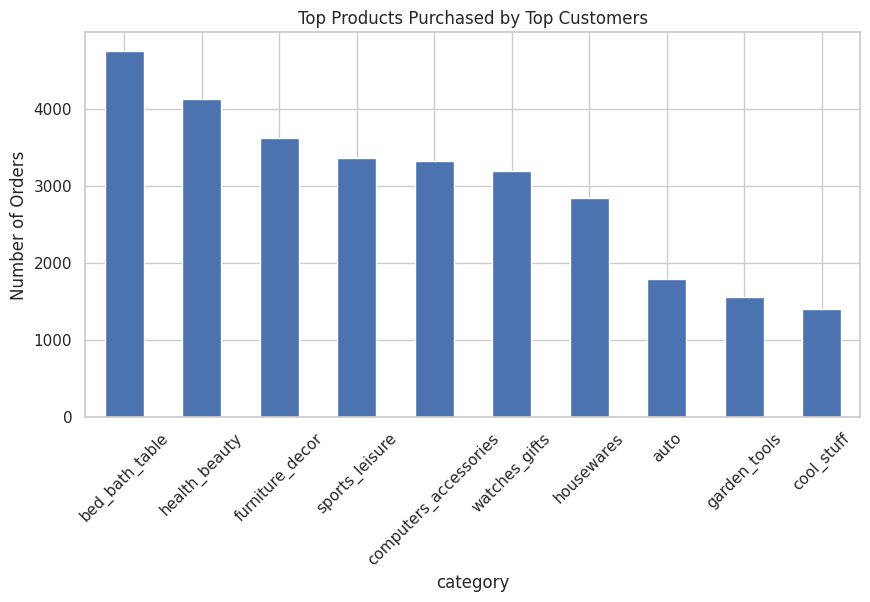

In [47]:
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title(f'Top Products Purchased by {top_segment}')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

**Insight:** (Opsional)
Berdasarkan analisis RFM, segmen dengan kontribusi revenue terbesar adalah Top Customers. Pada segmen ini, kategori bed_bath_table merupakan yang paling sering dibeli, menunjukkan pola pembelian yang bersifat rutin.

Namun, kategori health_beauty memberikan kontribusi revenue terbesar, yang berarti produk dalam kategori ini memiliki nilai transaksi yang lebih tinggi meskipun tidak sering dibeli.

Temuan ini menunjukkan bahwa frekuensi pembelian tidak selalu sejalan dengan nilai transaksi, sehingga perusahaan perlu menyeimbangkan strategi antara produk yang sering dibeli dan produk dengan nilai penjualan tinggi.

### Pertanyaan 2: Kategori produk apa yang paling banyak berkontribusi terhadap total revenue, dan bagaimana distribusi pembeliannya di setiap segmen pelanggan?


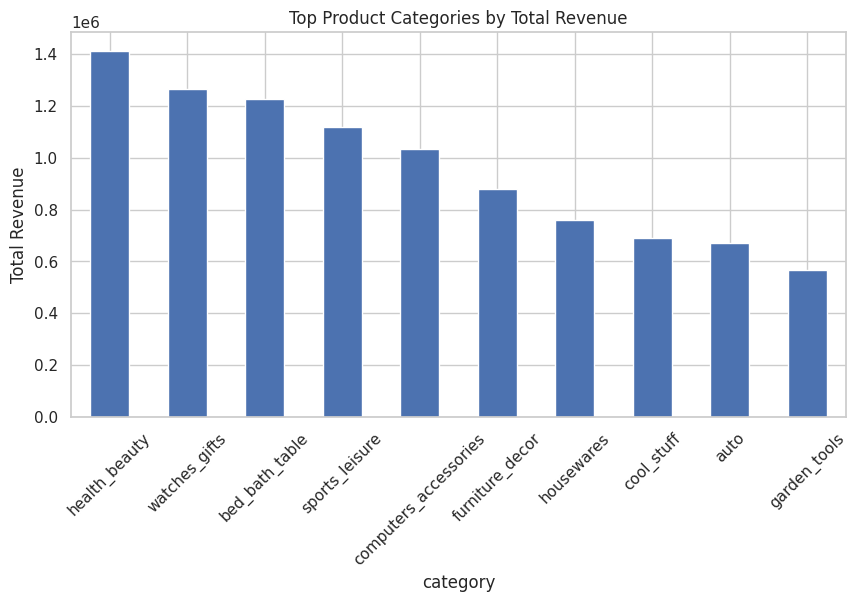

In [48]:
category_revenue = df_ne.groupby('category')['total_price'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

plt.figure(figsize=(10,5))
category_revenue.plot(kind='bar')
plt.title('Top Product Categories by Total Revenue')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [49]:
segment_category = df_ne.groupby(['category', 'segment'])['total_price'].sum().reset_index()

In [50]:
pivot = segment_category.pivot(
    index='category',
    columns='segment',
    values='total_price'
).fillna(0)

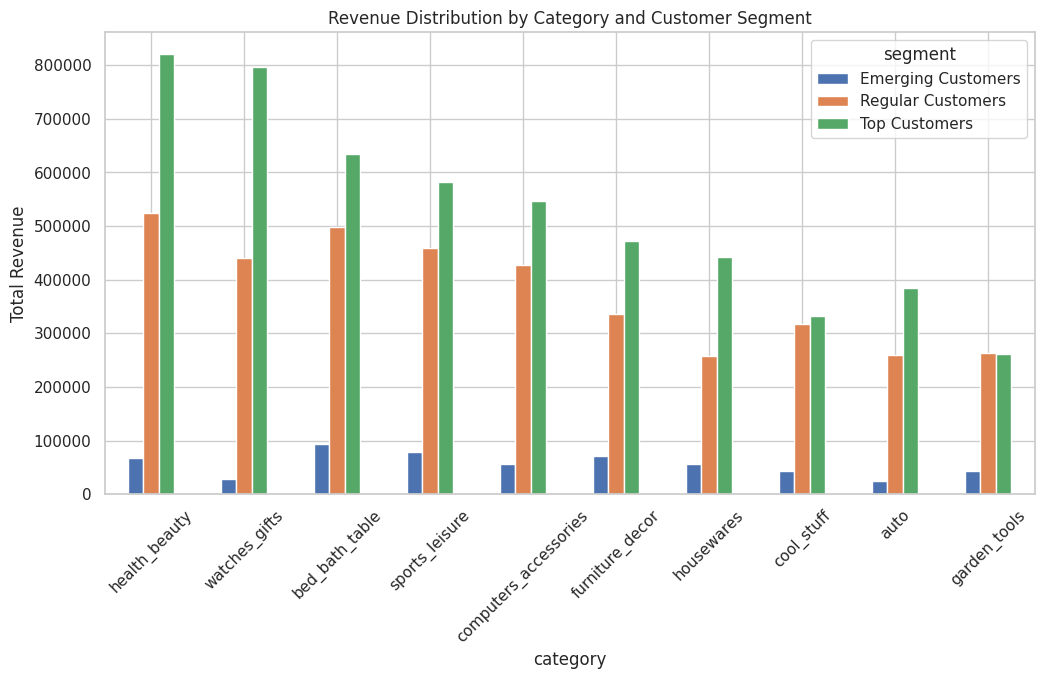

In [51]:
sorted_categories_by_revenue = pivot.sum(axis=1).sort_values(ascending=False).index
pivot.loc[sorted_categories_by_revenue].head(10).plot(kind='bar', figsize=(12,6))

plt.title('Revenue Distribution by Category and Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

**Insight:** (Opsional)
Berdasarkan analisis, kategori produk dengan kontribusi terbesar terhadap total revenue adalah kategori health_beauty. Hal ini menunjukkan bahwa kategori tersebut memiliki nilai transaksi yang tinggi dibandingkan kategori lainnya.

Ketika dianalisis lebih lanjut berdasarkan segmen pelanggan, terlihat bahwa kontribusi revenue dari kategori tersebut didominasi oleh segmen Top Customers.

### Pertanyaan 3: Bagaimana performa waktu pengiriman di berbagai wilayah, dan wilayah mana yang memiliki pengiriman paling cepat selama periode September 2016 - Oktober 2018?

In [52]:
shipping_by_state = df.groupby('customer_state')['shipping_duration'] \
    .agg(['mean', 'median', 'count']) \
    .sort_values(by='mean')

shipping_by_state.head()

,mean,median,count
customer_state,,,
SP,8.661828,7.0,45808
PR,11.880653,10.0,5572
MG,11.928151,10.0,12735
DF,12.892381,11.0,2323
SC,14.926449,13.0,4038


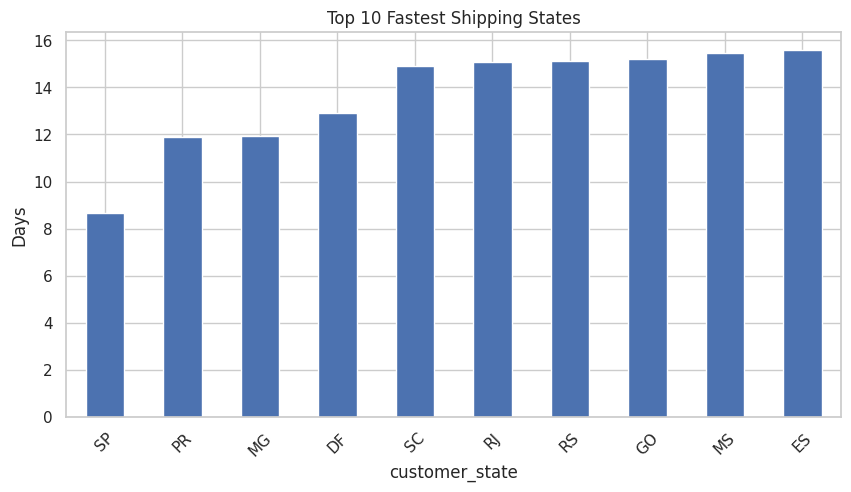

In [53]:
fastest_states = shipping_by_state.sort_values(by='mean').head(10)

plt.figure(figsize=(10,5))
fastest_states['mean'].plot(kind='bar')

plt.title('Top 10 Fastest Shipping States')
plt.ylabel('Days')
plt.xticks(rotation=45)
plt.show()

**Insight:** (Opsional)
Berdasarkan analisis waktu pengiriman di berbagai wilayah selama periode September 2016 hingga Oktober 2018, ditemukan bahwa performa pengiriman tidak merata antar wilayah. Wilayah dengan aktivitas tinggi seperti SP (São Paulo) menunjukkan rata-rata waktu pengiriman yang lebih cepat dibandingkan wilayah lainnya, yang mengindikasikan efisiensi logistik dan kedekatan dengan pusat distribusi. Sebaliknya, beberapa wilayah lain memiliki durasi pengiriman yang lebih lama serta variasi waktu yang lebih tinggi, menunjukkan adanya ketidakkonsistenan dalam proses pengiriman. Temuan ini menunjukkan bahwa faktor geografis dan infrastruktur distribusi sangat memengaruhi kecepatan pengiriman, sehingga perusahaan perlu mengoptimalkan strategi logistik di wilayah dengan performa yang lebih lambat untuk meningkatkan kecepatan dan konsistensi layanan.

## Analisis Lanjutan (Opsional)

In [55]:
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()
repeat_vs_one = customer_orders.apply(lambda x: 'Repeat' if x > 1 else 'One-time')
repeat_summary = repeat_vs_one.value_counts()

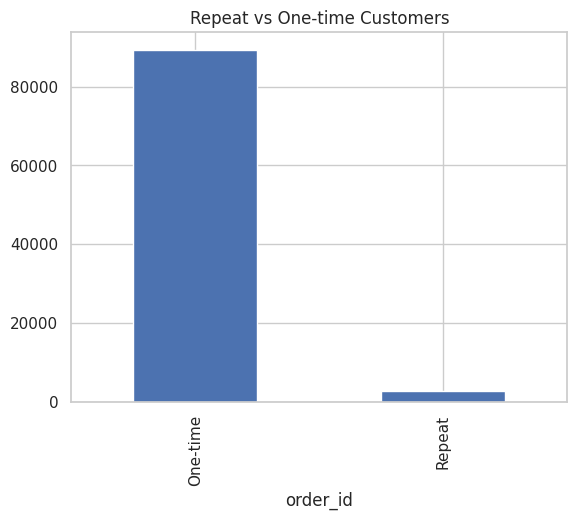

In [56]:
repeat_summary.plot(kind='bar')
plt.title('Repeat vs One-time Customers')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis RFM, segmen Top Customers merupakan kontributor terbesar terhadap total revenue. Segmen ini paling sering melakukan pembelian pada kategori bed_bath_table, yang menunjukkan adanya pola pembelian rutin. Namun, kategori health_beauty memberikan kontribusi revenue yang lebih tinggi, meskipun frekuensi pembeliannya lebih rendah. Hal ini menunjukkan bahwa frekuensi pembelian tidak selalu sejalan dengan nilai transaksi.
- **Conclusion pertanyaan 2:** Secara keseluruhan, kategori produk dengan kontribusi revenue terbesar berasal dari kategori bernilai tinggi seperti health_beauty. Namun, distribusi pembelian menunjukkan perbedaan antar segmen pelanggan, di mana Top Customers cenderung membeli produk dengan nilai transaksi tinggi dan segmen lainnya lebih banyak membeli produk dengan frekuensi tinggi namun nilai lebih rendah
- **Conclusion pertanyaan 3:** Analisis menunjukkan adanya variasi waktu pengiriman antar wilayah. Wilayah seperti SP (São Paulo) memiliki rata-rata waktu pengiriman yang lebih cepat dibandingkan wilayah lainnya, yang mengindikasikan performa logistik yang lebih efisien. Sebaliknya, beberapa wilayah lain memiliki durasi pengiriman yang lebih lama dan lebih bervariasi, yang berpotensi memengaruhi pengalaman pelanggan.

**Rekomendasi Action Item:**
- Fokus pada Retensi dan Nilai Pelanggan Utama
  Perusahaan perlu memprioritaskan segmen Top Customers melalui program loyalitas, penawaran eksklusif, dan personalisasi promosi. Hal ini penting karena segmen ini memberikan kontribusi terbesar terhadap revenue. Dengan menjaga hubungan dan meningkatkan pengalaman pelanggan, perusahaan dapat mempertahankan serta meningkatkan nilai transaksi dari pelanggan yang sudah terbukti loyal.

- Optimasi Strategi Produk Berdasarkan Performa
Strategi produk perlu dibedakan antara kategori dengan frekuensi tinggi dan kategori dengan nilai revenue tinggi. Produk dengan frekuensi tinggi seperti bed_bath_table dapat dimanfaatkan untuk menarik volume pembelian melalui promo atau bundling, sedangkan produk dengan kontribusi revenue tinggi seperti health_beauty dapat difokuskan pada strategi upselling dan positioning sebagai produk premium.

- Peningkatan Efisiensi Operasional dan Logistik
Perusahaan perlu mengoptimalkan performa pengiriman, khususnya di wilayah dengan durasi pengiriman yang lebih lama. Hal ini dapat dilakukan dengan mengevaluasi distribusi, meningkatkan efisiensi supply chain, serta mempertimbangkan penguatan infrastruktur logistik di wilayah tertentu.

In [57]:
# Simpan data transaksi periode analisis
df.to_csv("ecommerce_data.csv", index=False)

# Simpan data transaksi periode analisis
df_ne.to_csv("ecommerce_data_new.csv", index=False)

# Simpan hasil RFM
rfm.to_csv("rfm_data.csv")
print("File berhasil disimpan!")

File berhasil disimpan!
